In [1]:
import math
import torch
import gpytorch
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

import sys
sys.path.append("../../../")  

In [2]:
from pathlib import Path
import random
from learning.src.util.load_csv import load_csv, load_simulated_data

folders = sorted([f for f in Path("../../../Dataset").iterdir() if f.is_dir()])
#folders = sorted([l for l in Path("../../../results").iterdir() if l.is_dir()])
#folders = sorted([l for l in Path("../../../results").iterdir() if l.is_dir()] + [f for f in Path("../../../Dataset").iterdir() if f.is_dir()])
#folders = sorted([f for f in Path("../../../Dataset_no_force").iterdir() if f.is_dir()])
random.seed(42)
random.shuffle(folders)

n = len(folders)
train_folders = folders[:int(0.8 * n)]
val_folders   = folders[int(0.8 * n):int(0.9 * n)]
test_folders  = folders[int(0.9 * n):]

def load_folders(folder_list):
    all_x, all_y = [], []
    for folder in folder_list:
        x, y = load_simulated_data(folder)
        all_x.append(x)
        all_y.append(y)
    return torch.cat(all_x, dim=0), torch.cat(all_y, dim=0)

train_x, train_y = load_folders(train_folders)
val_x,   val_y   = load_folders(val_folders)
test_x,  test_y  = load_folders(test_folders)

In [3]:
train_x.shape, train_y.shape, val_x.shape, val_y.shape, test_x.shape, test_y.shape

(torch.Size([56056, 7]),
 torch.Size([56056, 60]),
 torch.Size([7007, 7]),
 torch.Size([7007, 60]),
 torch.Size([7007, 7]),
 torch.Size([7007, 60]))

In [3]:
test_x.shape, test_y.shape

(torch.Size([7007, 7]), torch.Size([7007, 60]))

In [4]:
# only for after evaluation
from learning.models.multitaskGP import load_model


model, likelihood = load_model("../../../learning/models/latent5_lr0,005_inducing64/gp_model_old_data.pth")

def evaluate(model, likelihood, x, y):
    model.eval()
    likelihood.eval()
    with torch.no_grad(): #, gpytorch.settings.fast_pred_var()
        preds = likelihood(model(x))
        rmse = (preds.mean - y).pow(2).mean().sqrt().item()
        nll  = -preds.log_prob(y).mean().item()
    return rmse, nll

test_rmse, test_nll = evaluate(model, likelihood, test_x, test_y)
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test NLL:  {test_nll:.4f}")

Test RMSE: 0.0124
Test NLL:  -1302867.6250


In [ ]:
print(likelihood.noise)                        # should be reasonable, not near 0
print(model.covar_module.outputscale) 

tensor([1.0000e-04], grad_fn=<AddBackward0>)
tensor([3.5251e+00, 2.1126e-03, 6.4507e+00, 1.9445e-03, 3.1515e-01],
       grad_fn=<SoftplusBackward0>)


In [ ]:
from learning.models.multitaskGP import MultitaskGPModel

num_latents = 5 # number of latent functions
num_tasks = train_y.shape[1] # number of outputs 
num_inputs = train_x.shape[1] # number of input dimensions

model = MultitaskGPModel(num_latents, num_tasks, num_inputs)
likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=num_tasks)

Epoch:   0%|          | 0/250 [00:00<?, ?it/s]

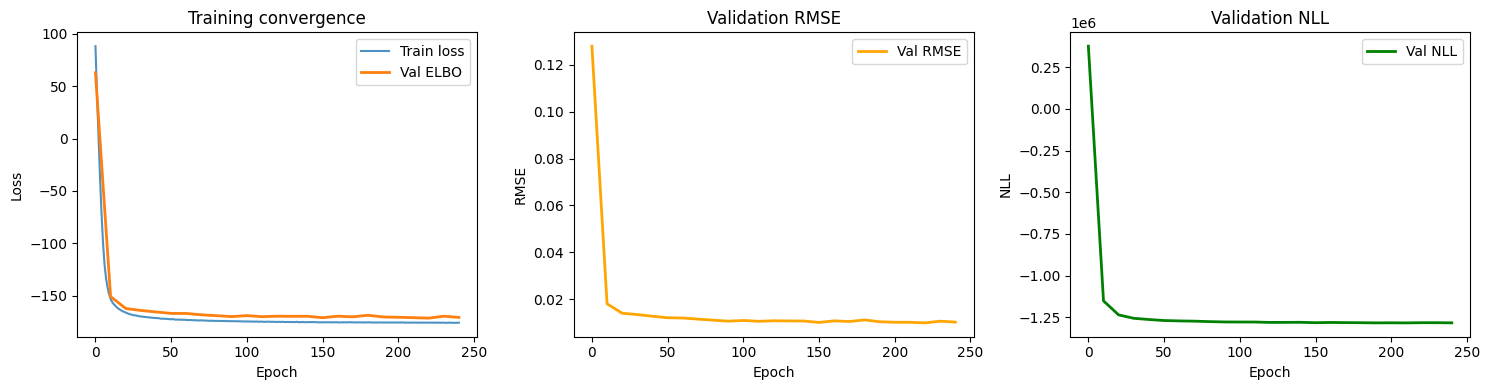

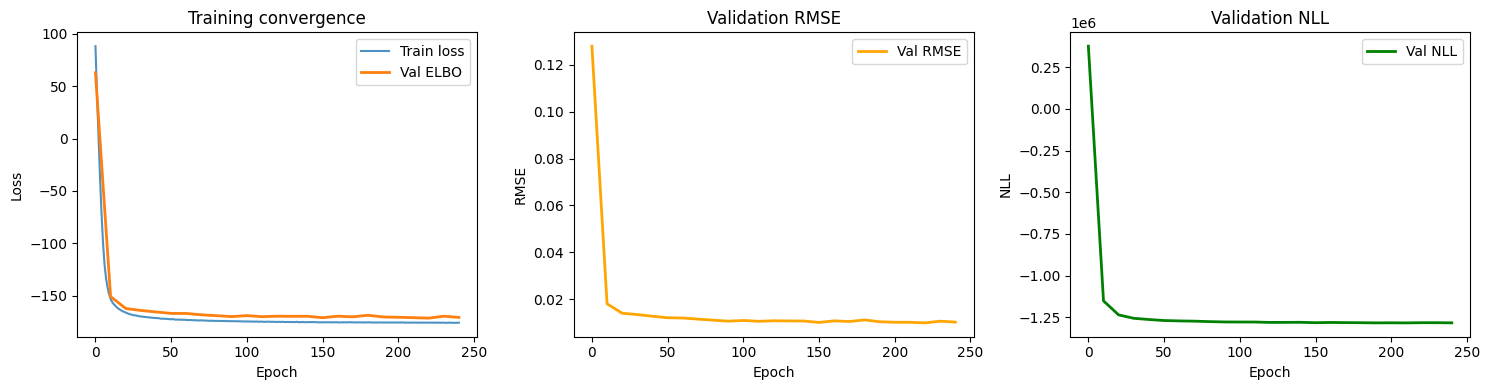

In [ ]:
import os
smoke_test = ('CI' in os.environ)
num_epochs = 1 if smoke_test else 250
epochs_iter = tqdm(range(num_epochs), desc="Epoch")

model.train()
likelihood.train()

optimizer = torch.optim.Adam([
    {'params': model.parameters()},
    {'params': likelihood.parameters()},
], lr=0.005)


from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_x, train_y)
train_loader  = DataLoader(train_dataset, batch_size=256, shuffle=True)

mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(train_dataset))

def evaluate(model, likelihood, x, y, mll):
    model.eval()
    likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        preds = likelihood(model(x))
        val_loss = -mll(model(x), y).item()   # validation ELBO
        rmse = (preds.mean - y).pow(2).mean().sqrt().item()
        nll  = -preds.log_prob(y).mean().item()
    return val_loss, rmse, nll

import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# --- setup ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plt.tight_layout()
display_handle = display(fig, display_id=True)

def update_plots(train_losses, val_elbos, val_rmses, val_nlls):
    val_e_epochs, val_e_values = zip(*val_elbos)
    val_r_epochs, val_r_values = zip(*val_rmses)
    val_n_epochs, val_n_values = zip(*val_nlls)

    for ax in axes:
        ax.cla()

    axes[0].plot(train_losses, label="Train loss", alpha=0.8)
    axes[0].plot(val_e_epochs, val_e_values, label="Val ELBO", linewidth=2)
    axes[0].set(xlabel="Epoch", ylabel="Loss", title="Training convergence")
    axes[0].legend()

    axes[1].plot(val_r_epochs, val_r_values, label="Val RMSE", color="orange", linewidth=2)
    axes[1].set(xlabel="Epoch", ylabel="RMSE", title="Validation RMSE")
    axes[1].legend()

    axes[2].plot(val_n_epochs, val_n_values, label="Val NLL", color="green", linewidth=2)
    axes[2].set(xlabel="Epoch", ylabel="NLL", title="Validation NLL")
    axes[2].legend()

    fig.tight_layout()
    display_handle.update(fig)



train_losses = []
val_elbos = []
val_rmses = []
val_nlls = []

for i in epochs_iter:
    model.train(); likelihood.train()
    batch_losses = []
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(x_batch)
        loss = -mll(output, y_batch) # type: ignore
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_losses.append(sum(batch_losses) / len(batch_losses))

    if i % 10 == 0:
        val_elbo, val_rmse, val_nll = evaluate(model, likelihood, val_x, val_y, mll)
        val_elbos.append((i, val_elbo))
        val_rmses.append((i, val_rmse))
        val_nlls.append((i, val_nll))
        epochs_iter.set_postfix(train_loss=loss.item(), val_rmse=val_rmse, val_nll=val_nll, val_elbo=val_elbo) # type: ignore
        update_plots(train_losses, val_elbos, val_rmses, val_nlls)


In [ ]:
# start_epoch = len(train_losses)
# num_extra_epochs = 100
# epochs_iter = tqdm(range(start_epoch, start_epoch + num_extra_epochs), desc="Epoch")
# for i in epochs_iter:
#     model.train(); likelihood.train()
#     batch_losses = []
#     for x_batch, y_batch in train_loader:
#         optimizer.zero_grad()
#         output = model(x_batch)
#         loss = -mll(output, y_batch) # type: ignore
#         loss.backward()
#         optimizer.step()
#         batch_losses.append(loss.item())

#     train_losses.append(sum(batch_losses) / len(batch_losses))

#     if i % 10 == 0:
#         val_elbo, val_rmse, val_nll = evaluate(model, likelihood, val_x, val_y, mll)
#         val_elbos.append((i, val_elbo))
#         val_rmses.append((i, val_rmse))
#         val_nlls.append((i, val_nll))
#         epochs_iter.set_postfix(train_loss=loss.item(), val_rmse=val_rmse, val_nll=val_nll, val_elbo=val_elbo) # type: ignore
#         update_plots(train_losses, val_elbos, val_rmses, val_nlls)

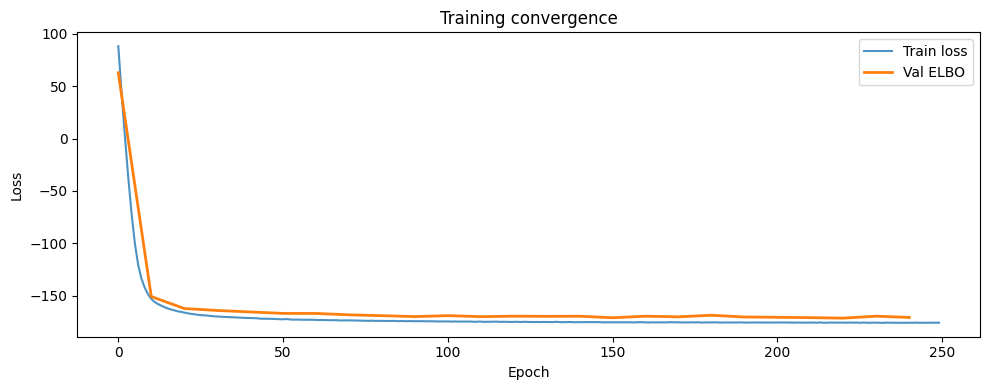

In [ ]:
val_epochs, val_values = zip(*val_elbos)


plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train loss", alpha=0.8)
plt.plot(val_epochs, val_values, label="Val ELBO", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training convergence")
plt.legend()
plt.tight_layout()
plt.show()

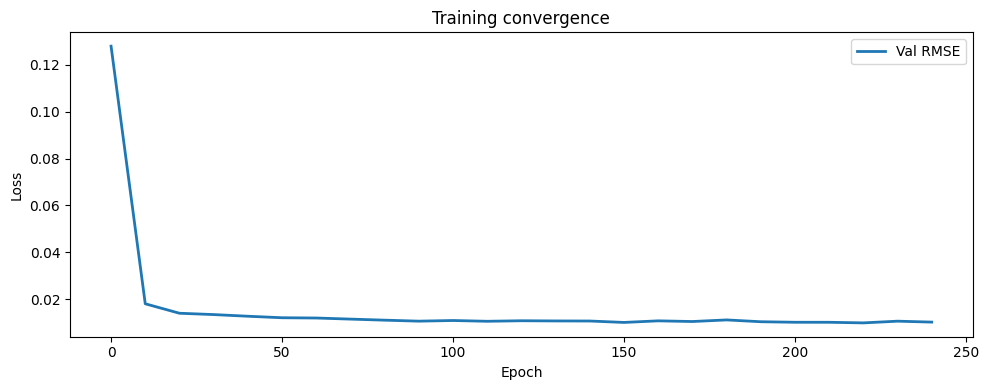

In [ ]:
val_epochs, val_values = zip(*val_rmses)

plt.figure(figsize=(10, 4))
plt.plot(val_epochs, val_values, label="Val RMSE", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training convergence")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
test_elbo, test_rmse, test_nll = evaluate(model, likelihood, test_x, test_y, mll)
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test NLL:  {test_nll:.4f}")
print(f"Test ELBO: {test_elbo:.4f}")

Test RMSE: 0.0072
Test NLL:  -1289681.2500
Test ELBO: -176.0691


In [ ]:
# model.eval(); likelihood.eval()
# with torch.no_grad(), gpytorch.settings.fast_pred_var():
#     preds = likelihood(model(test_x))
#     per_output_rmse = (preds.mean - test_y).pow(2).mean(dim=0).sqrt()

# # Reshape to (20 nodes, 3 coords) for readability
# per_output_rmse = per_output_rmse.reshape(20, 3)
# for node_idx, (x, y, z) in enumerate(per_output_rmse):
#     print(f"Node {node_idx:2d} — x: {x:.4f}, y: {y:.4f}, z: {z:.4f}")

In [ ]:
# # Set into eval mode
# model.eval()
# likelihood.eval()

# # Initialize plots
# fig, axs = plt.subplots(1, num_tasks, figsize=(4 * num_tasks, 3))

# # Make predictions
# with torch.no_grad(), gpytorch.settings.fast_pred_var():
#     test_x = torch.zeros(51, num_inputs)
#     test_x[:, 0] = torch.linspace(0, 1, 51)
#     predictions = likelihood(model(test_x))
#     mean = predictions.mean
#     lower, upper = predictions.confidence_region() # type: ignore

# for task, ax in enumerate(axs):
#     # Plot training data as black stars (only x[:,0])
#     ax.scatter(train_x[:, 0].detach().numpy(), train_y[:, task].detach().numpy(), c='k', marker='*')
#     # Predictive mean as blue line
#     ax.plot(test_x[:, 0].numpy(), mean[:, task].numpy(), 'b')
#     # Shade in confidence
#     ax.fill_between(test_x[:, 0].numpy(), lower[:, task].numpy(), upper[:, task].numpy(), alpha=0.5)
#     ax.set_ylim([-3, 3])
#     ax.legend(['Observed Data', 'Mean', 'Confidence'])
#     ax.set_title(f'Task {task + 1}')

# fig.tight_layout()
# None

In [ ]:
# #test of model
# model.eval()
# likelihood.eval()

# # Make predictions
# with torch.no_grad(), gpytorch.settings.fast_pred_var():
#     test_x = torch.rand(1, num_inputs)
#     predictions = likelihood(model(test_x))
#     mean = predictions.mean
#     lower, upper = predictions.confidence_region() # type: ignore

In [ ]:
import torch

# Save the model and likelihood
torch.save({
    'model_state_dict': model.state_dict(),
    'likelihood_state_dict': likelihood.state_dict(),
    'num_latents': num_latents,
    'num_tasks': num_tasks,
    'num_inputs': num_inputs
}, '../../models/latent5_lr0,005_inducing64/gp_model_new_data.pth')

print("Model saved to 'models/latent5_lr0,005_inducing64/gp_model_new_data.pth'")

Model saved to 'models/latent5_lr0,005_inducing64/gp_model_new_data.pth'


In [ ]:
# import torch
# import gpytorch

# # Load the checkpoint
# checkpoint = torch.load('../../models/gp_model.pth')

# # Recreate the model with the saved hyperparameters
# model = MultitaskGPModel(
#     num_latents=checkpoint['num_latents'],
#     num_tasks=checkpoint['num_tasks'],
#     num_inputs=checkpoint['num_inputs']
# )

# # Load the saved state dictionaries
# model.load_state_dict(checkpoint['model_state_dict'])

# likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=checkpoint['num_tasks'])
# likelihood.load_state_dict(checkpoint['likelihood_state_dict'])

# # Set to evaluation mode (important for inference)
# model.eval()
# likelihood.eval()

# print("Model reloaded from 'models/gp_model.pth'")